# Bagging

### Why averaging unstable models makes a stable one

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a bootstrap sample is, why averaging cuts variance and leaves bias alone, which models bagging helps and which it cannot, and where out-of-bag scoring comes from |
| **You should already know** | [Decision trees](../../03-classification/06-decision-trees/), [overfitting](../../01-foundations/03-overfitting-and-underfitting/) |
| **Dataset** | UCI Dry Bean, California Housing |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [04-02 Random forests](../02-random-forest/) |

---

## 1. The idea

[Overfitting](../../01-foundations/03-overfitting-and-underfitting/) split model
error into two parts. **Bias** is being wrong the same way every time. **Variance**
is being wrong a different way every time.

Bagging attacks the second one, using a fact about averages. If you average $B$
independent estimates each with variance $\sigma^2$, the average has variance
$\sigma^2 / B$. The individual errors point in different directions and cancel;
the signal is common to all of them and survives.

The obstacle is that you have one training set, not $B$ of them. **Bootstrapping**
fakes it: draw $n$ rows *with replacement* from your $n$ rows. Each draw is a
slightly different dataset, so each model trained on one is a slightly different
model.

Bagging is "bootstrap aggregating", and that is the whole method.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. What a bootstrap sample looks like

One consequence of drawing with replacement is worth knowing, because the next
notebook depends on it. The chance a given row is *never* picked in $n$ draws is
$(1 - 1/n)^n$, which converges to $1/e \approx 0.368$.

**About 37% of rows are missing from every bootstrap sample.** Those rows are a
free validation set for the model trained on that sample — the "out-of-bag" idea.

In [2]:
rng = np.random.default_rng(SEED)
for n in [10, 100, 1000, 20000]:
    draws = rng.integers(0, n, (200, n))
    left_out = np.mean([len(set(range(n)) - set(row)) / n for row in draws[:40]])
    print(f"n = {n:>6}: {left_out:.3%} of rows left out on average   (theory: {(1 - 1/n)**n:.3%})")

n =     10: 36.500% of rows left out on average   (theory: 34.868%)
n =    100: 36.500% of rows left out on average   (theory: 36.603%)
n =   1000: 36.748% of rows left out on average   (theory: 36.770%)
n =  20000: 36.790% of rows left out on average   (theory: 36.787%)


## 3. Watching variance disappear

The clearest demonstration is on a single feature, where the fitted function can
be drawn.

variance across 25 trees   : 0.0563
variance across 25 linears : 0.0099

error of the average tree  : 0.0475
error of a typical tree    : 0.1037


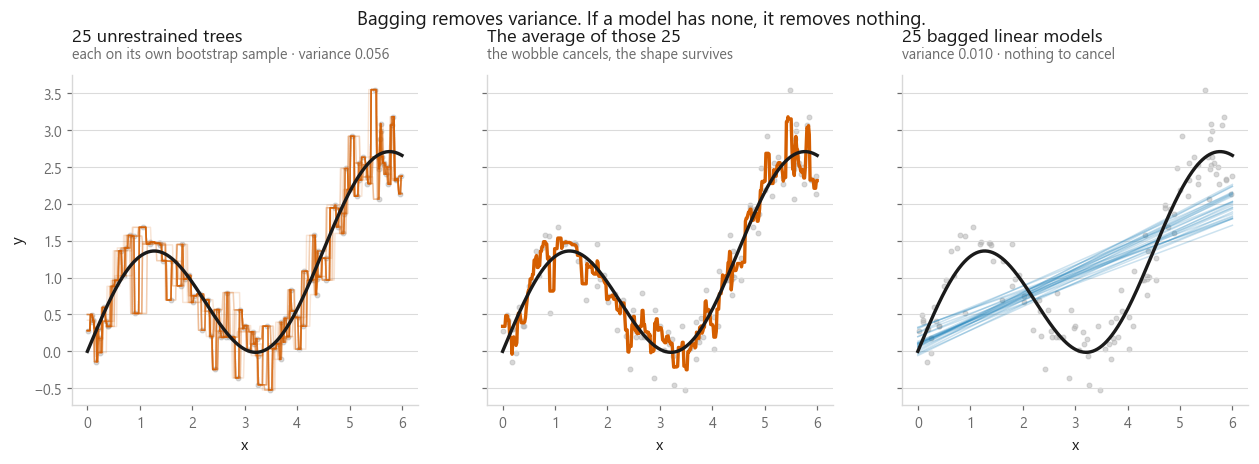

In [3]:
from sklearn.tree import DecisionTreeRegressor

truth = lambda x: np.sin(1.4 * x) + 0.3 * x
x_grid = np.linspace(0, 6, 400)

fig, axes = plt.subplots(1, 3, figsize=(13.8, 3.9), sharey=True)

# Panel 1: single trees, each on its own bootstrap sample
sample_rng = np.random.default_rng(SEED)
base_x = np.sort(sample_rng.uniform(0, 6, 120))
base_y = truth(base_x) + sample_rng.normal(0, 0.3, 120)

predictions = []
for trial in range(25):
    idx = sample_rng.integers(0, len(base_x), len(base_x))
    tree = DecisionTreeRegressor(max_depth=None, random_state=trial)
    tree.fit(base_x[idx, None], base_y[idx])
    curve = tree.predict(x_grid[:, None])
    predictions.append(curve)
    axes[0].plot(x_grid, curve, color=style.HIGHLIGHT, alpha=0.16, lw=1)
predictions = np.array(predictions)

axes[0].plot(x_grid, truth(x_grid), color=style.INK, lw=2.2)
axes[0].scatter(base_x, base_y, s=10, c=style.NEUTRAL, alpha=0.5, zorder=0)
style.title(axes[0], "25 unrestrained trees",
            f"each on its own bootstrap sample · variance {predictions.var(axis=0).mean():.3f}")

# Panel 2: their average
axes[1].plot(x_grid, predictions.mean(axis=0), color=style.HIGHLIGHT, lw=2.2)
axes[1].plot(x_grid, truth(x_grid), color=style.INK, lw=2.2)
axes[1].scatter(base_x, base_y, s=10, c=style.NEUTRAL, alpha=0.5, zorder=0)
style.title(axes[1], "The average of those 25", "the wobble cancels, the shape survives")

# Panel 3: bagging a linear model, which has almost no variance to remove
from sklearn.linear_model import LinearRegression

linear_predictions = []
for trial in range(25):
    idx = sample_rng.integers(0, len(base_x), len(base_x))
    model = LinearRegression().fit(base_x[idx, None], base_y[idx])
    curve = model.predict(x_grid[:, None])
    linear_predictions.append(curve)
    axes[2].plot(x_grid, curve, color=style.PALETTE[0], alpha=0.20, lw=1)
linear_predictions = np.array(linear_predictions)

axes[2].plot(x_grid, truth(x_grid), color=style.INK, lw=2.2)
axes[2].scatter(base_x, base_y, s=10, c=style.NEUTRAL, alpha=0.5, zorder=0)
style.title(axes[2], "25 bagged linear models",
            f"variance {linear_predictions.var(axis=0).mean():.3f} · nothing to cancel")

axes[0].set_ylabel("y")
for ax in axes:
    ax.set_xlabel("x")
fig.suptitle("Bagging removes variance. If a model has none, it removes nothing.",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-variance-cancels.png")

print(f"variance across 25 trees   : {predictions.var(axis=0).mean():.4f}")
print(f"variance across 25 linears : {linear_predictions.var(axis=0).mean():.4f}")
print(f"\nerror of the average tree  : {np.mean((predictions.mean(axis=0) - truth(x_grid))**2):.4f}")
print(f"error of a typical tree    : {np.mean((predictions - truth(x_grid))**2):.4f}")

The left panel is a mess of overfitted step functions, each chasing its own
sample. The middle panel is their average, and it tracks the real curve closely.
Nothing was regularised, nothing was pruned — the wobble simply cancelled.

The right panel is the control, and it is the part people skip. **Bagged linear
models are pointless.** A straight line barely changes between bootstrap samples,
so there is no variance to average away, and 25 nearly identical lines average to
the same line.

**Bagging helps unstable models and does nothing for stable ones.** That is the
rule for deciding whether to reach for it.

## 4. On real data

tree     0.8945 -> bagged 0.9237  (+0.0292)
logistic 0.9234 -> bagged 0.9239  (+0.0005)


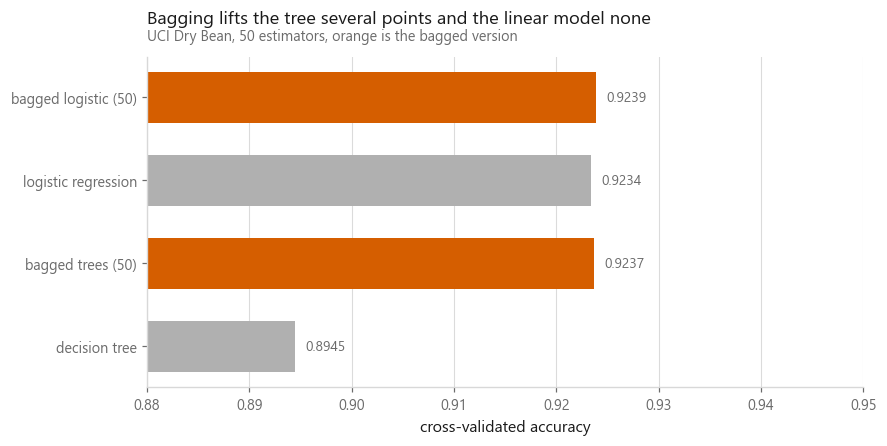

In [4]:
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

X, y = datasets.dry_bean()
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

pairs = {
    "decision tree": DecisionTreeClassifier(random_state=SEED),
    "bagged trees (50)": BaggingClassifier(DecisionTreeClassifier(random_state=SEED),
                                           n_estimators=50, n_jobs=-1, random_state=SEED),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "bagged logistic (50)": make_pipeline(
        StandardScaler(),
        BaggingClassifier(LogisticRegression(max_iter=3000), n_estimators=50,
                          n_jobs=-1, random_state=SEED)),
}

scores = {name: cross_val_score(model, X.values, y.values, cv=folds, n_jobs=-1).mean()
          for name, model in pairs.items()}

fig, ax = plt.subplots(figsize=(8.4, 3.9))
names = list(scores)
colours = [style.NEUTRAL, style.HIGHLIGHT, style.NEUTRAL, style.HIGHLIGHT]
ax.barh(names, [scores[n] for n in names], color=colours, height=0.62)
for i, n in enumerate(names):
    ax.text(scores[n] + 0.001, i, f"{scores[n]:.4f}", va="center", fontsize=9, color=style.MUTED)
ax.set_xlim(0.88, 0.95)
ax.set_xlabel("cross-validated accuracy")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
style.title(ax, "Bagging lifts the tree several points and the linear model none",
            "UCI Dry Bean, 50 estimators, orange is the bagged version")
style.save(fig, FIG / "fig-02-what-it-helps.png")

print(f"tree     {scores['decision tree']:.4f} -> bagged {scores['bagged trees (50)']:.4f}  "
      f"({scores['bagged trees (50)'] - scores['decision tree']:+.4f})")
print(f"logistic {scores['logistic regression']:.4f} -> bagged {scores['bagged logistic (50)']:.4f}  "
      f"({scores['bagged logistic (50)'] - scores['logistic regression']:+.4f})")

### How many estimators?

1 estimator   : 0.8918
20 estimators : 0.9232
200 estimators: 0.9251   (gain from 20 to 200: +0.0019)


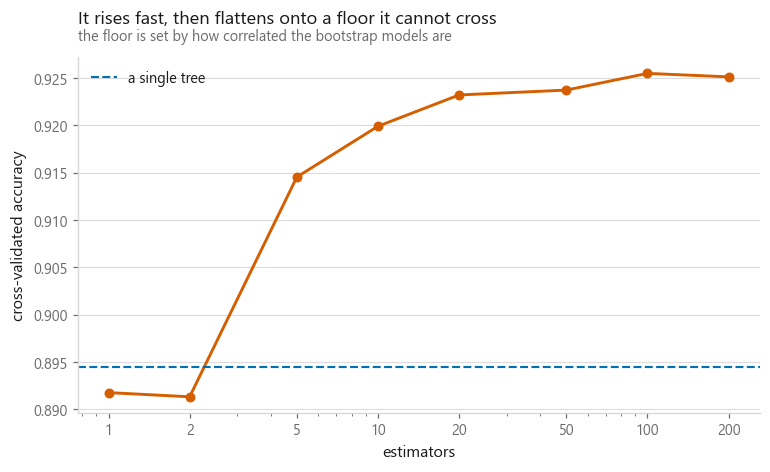

In [5]:
counts = [1, 2, 5, 10, 20, 50, 100, 200]
curve = [cross_val_score(BaggingClassifier(DecisionTreeClassifier(random_state=SEED),
                                           n_estimators=n, n_jobs=-1, random_state=SEED),
                         X.values, y.values, cv=folds, n_jobs=1).mean()
         for n in counts]

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(counts, curve, marker=style.MARKERS[0], color=style.HIGHLIGHT)
ax.axhline(scores["decision tree"], color=style.PALETTE[0], ls="--", lw=1.4,
           label="a single tree")
ax.set_xscale("log")
ax.set_xticks(counts, [str(c) for c in counts])
ax.set_xlabel("estimators")
ax.set_ylabel("cross-validated accuracy")
ax.legend()
style.title(ax, "It rises fast, then flattens onto a floor it cannot cross",
            "the floor is set by how correlated the bootstrap models are")
style.save(fig, FIG / "fig-03-how-many.png")

print(f"1 estimator   : {curve[0]:.4f}")
print(f"20 estimators : {curve[4]:.4f}")
print(f"200 estimators: {curve[-1]:.4f}   (gain from 20 to 200: {curve[-1]-curve[4]:+.4f})")

More estimators never hurt, and after about twenty they barely help. The floor
exists because bootstrap samples of the same data produce **correlated** models —
they overlap in roughly 63% of their rows. Averaging cannot cancel errors the
models make in common.

Pushing that correlation down is exactly what
[random forests](../02-random-forest/) add, by also subsampling features at every
split.

## 5. Out-of-bag scoring, for free

Each model skipped about 37% of the rows. Score every row using only the models
that did not see it, and you have a held-out estimate with no extra fitting and
no cross-validation loop.

In [6]:
import time

X_num, y_num = X.values, y.values

start = time.perf_counter()
oob_model = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=100,
                              oob_score=True, n_jobs=-1, random_state=SEED).fit(X_num, y_num)
oob_time = time.perf_counter() - start

start = time.perf_counter()
cv_score = cross_val_score(BaggingClassifier(DecisionTreeClassifier(random_state=SEED),
                                             n_estimators=100, n_jobs=-1, random_state=SEED),
                           X_num, y_num, cv=folds, n_jobs=1).mean()
cv_time = time.perf_counter() - start

print(f"out-of-bag score : {oob_model.oob_score_:.4f}   ({oob_time:.1f} s, one fit)")
print(f"5-fold CV score  : {cv_score:.4f}   ({cv_time:.1f} s, five fits)")
print(f"difference       : {abs(oob_model.oob_score_ - cv_score):.4f}")
print(f"speed-up         : {cv_time / oob_time:.1f}x")

out-of-bag score : 0.9239   (3.2 s, one fit)
5-fold CV score  : 0.9255   (12.2 s, five fits)
difference       : 0.0016
speed-up         : 3.8x


The two agree closely, and the out-of-bag version costs one fit instead of five.
On a large dataset that is a real saving, and it is why
[random forests](../02-random-forest/) expose `oob_score=True`.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Your base model is unstable — deep trees, k-NN with small k, anything that changes a lot when the data changes a little |
| **Do not bother when** | The base model is already stable. Bagged linear or naive Bayes models gain essentially nothing |
| **What it fixes** | Variance. It leaves bias exactly where it was — bagging a underfitting model gives an underfitting ensemble |
| **Estimators** | More never hurts accuracy. Twenty gets most of it; a hundred is a safe default |
| **Free extra** | `oob_score=True` gives a validation estimate for one fit instead of five |
| **Next** | [Random forests](../02-random-forest/), which decorrelate the trees further and usually beat plain bagging |

## What to remember

1. Bootstrap = sample $n$ rows with replacement. About 37% get left out each time.
2. Averaging $B$ models cuts variance toward $\sigma^2/B$ and leaves bias untouched.
3. Bagging helps unstable models. On a stable one it does nothing at all.
4. The gain flattens because bootstrap models share most of their data and so
   share most of their mistakes.
5. Those left-out rows give you free validation.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-02 Random forests](../02-random-forest/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Bagging` `#Ensemble` `#Bootstrap` `#DecisionTrees`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#VarianceReduction`